In [21]:
!pip uninstall community -y
!pip install python-louvain

Found existing installation: community 1.0.0b1
Uninstalling community-1.0.0b1:
  Successfully uninstalled community-1.0.0b1
  Using cached python-louvain-0.16.tar.gz (204 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9474 sha256=2afb2561229f0b12dee04556d6b40cf1ab5642f5de83e2a936eba9bf1bb7c509
  Stored in directory: c:\users\rengan\appdata\local\pip\cache\wheels\ee\52\54\7ecd0f1ebf5f5a8466f70a27ed2b94d20b955376879d6159c5
Successfully built python-louvain


In [9]:
# ============================================================
# CELL 1 — PATH SETUP (run this first, every session)
# ============================================================
import os, sys
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Resolve project root robustly — works whether notebook is in
# notebooks/ subfolder OR run directly from the project root
_cwd = os.getcwd()

# If running from inside a subfolder (e.g. notebooks/), go up one level
if not os.path.exists(os.path.join(_cwd, 'Data')):
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, '..'))
else:
    PROJECT_ROOT = _cwd

DATA_DIR   = os.path.join(PROJECT_ROOT, 'Data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'Outputs')
UTILS_DIR  = PROJECT_ROOT

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Add Utils to import path
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}    {'✅' if os.path.exists(DATA_DIR) else '❌ NOT FOUND'}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}  {'✅' if os.path.exists(OUTPUT_DIR) else '✅ created'}")

PROJECT_ROOT : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike
DATA_DIR     : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\Data    ✅
OUTPUT_DIR   : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\Outputs  ✅


In [10]:
# ============================================================
# NOTEBOOK 03 — Network Construction & Analysis
# ============================================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from Utils.network_builder import (
    build_user_cocomment_network,
    build_channel_interaction_network,
    compute_network_metrics,
    detect_communities,
    plot_network,
)

# ---------- Load processed data ----------
videos_df   = pd.read_csv('../Data/videos_processed.csv')
comments_df = pd.read_csv('../Data/comments_processed.csv')





17:18:58 [INFO] Co-comment network: 10530 nodes, 428 edges (min_shared=2)
17:18:58 [INFO] Running Louvain community detection (python-louvain)...


Co-comment Network | Nodes: 10530 | Edges: 428
Network density: 0.0000
Is connected: False
Number of components: 10346
Largest component size: 85


17:18:59 [INFO] Louvain: 10351 communities detected
17:18:59 [INFO] Computing centrality for 10530 nodes...
17:18:59 [INFO] Centrality computation complete.
17:18:59 [INFO] Computing spring layout for 100 nodes...



Louvain Communities detected: 10351
Top 5 communities by size:
  Community 8: 27 users
  Community 7: 27 users
  Community 23: 26 users
  Community 0: 20 users
  Community 2: 15 users

Top 10 most influential users (by PageRank):
                    node  degree  degree_c  pagerank  betweenness_c  closeness_c
UC-pOuec9Q_RiRlk7Tl3ek4Q      57  0.333333  0.052414       0.386082     0.528302
UCxyMX8FuRJmeURX5CkFxy0Q      48  0.285714  0.050996       0.298805     0.482759
UCPu2CzLwpQjZH8j34l7sjUw      48  0.273810  0.042080       0.184466     0.525000
UClYebRHQFf6mybTn2DpZQFw      22  0.130952  0.030158       0.163985     0.432990
UCLVwXRBE0sdzLszaqn2uzeg      37  0.214286  0.030121       0.134896     0.491228
UCvXDgLBzF1dwV27q64khEiw      31  0.178571  0.029174       0.149008     0.442105
UC294I3eDpbT5DE2shfMIzxg      27  0.154762  0.028908       0.151855     0.415842
UCDubLFjcawZ0LVUNzyA5jaQ      28  0.166667  0.024314       0.059957     0.432990
UCHbmqlqce_z3LCd-SeOZIFw      18  0.1071

17:18:59 [INFO] Saved: ../Outputs/02_cocomment_network.png


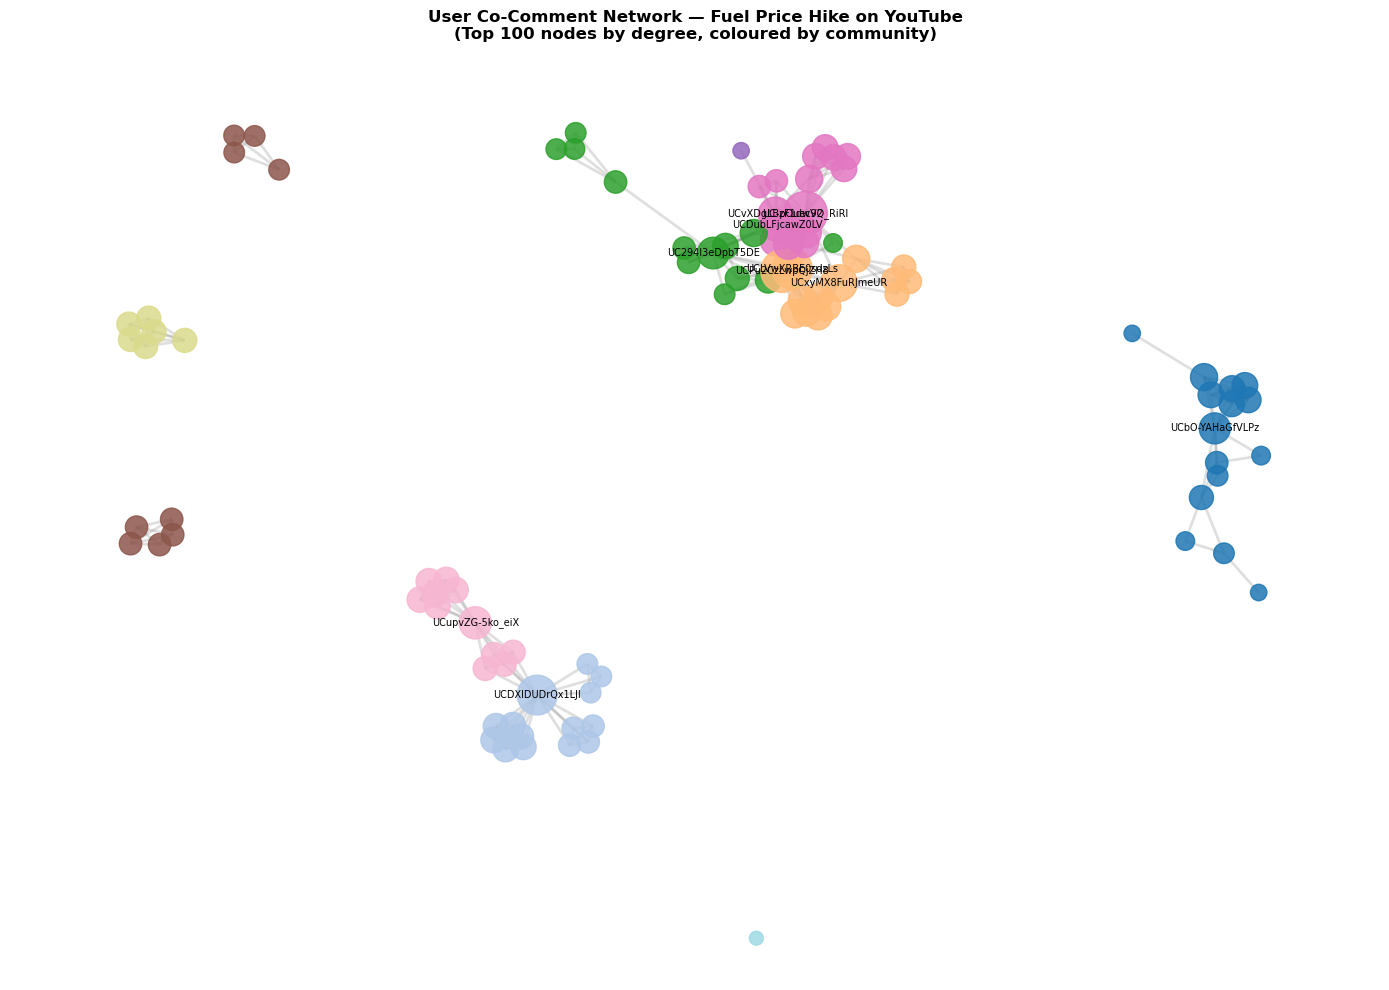

In [11]:
# ============================================================
# GRAPH 1: User Co-Comment Network (Undirected, Weighted)
# Nodes  = YouTube commenters (author_id)
# Edges  = Two users commented on the SAME video
# Weight = Number of shared videos commented on
# Why undirected? Co-occurrence has no directionality.
# Why weighted?   More shared videos = stronger relationship.
# ============================================================
G_cocomment = build_user_cocomment_network(
    comments_df,
    min_shared_videos=2   # threshold: filter noise
)

print(f"Co-comment Network | Nodes: {G_cocomment.number_of_nodes()} | "
      f"Edges: {G_cocomment.number_of_edges()}")
print(f"Network density: {nx.density(G_cocomment):.4f}")
print(f"Is connected: {nx.is_connected(G_cocomment)}")

# Connected components
components = list(nx.connected_components(G_cocomment))
print(f"Number of components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")

# ---------- Community Detection (Louvain) ----------
partition = detect_communities(G_cocomment)
num_communities = len(set(partition.values()))
print(f"\nLouvain Communities detected: {num_communities}")

# Community size distribution
from collections import Counter
community_sizes = Counter(partition.values())
print("Top 5 communities by size:")
for cid, size in community_sizes.most_common(5):
    print(f"  Community {cid}: {size} users")

# ---------- Centrality Measures ----------
metrics_df = compute_network_metrics(G_cocomment)
print("\nTop 10 most influential users (by PageRank):")
print(metrics_df.head(10).to_string(index=False))
metrics_df.to_csv('../Data/network_metrics.csv', index=False)

# ---------- Network Visualisation ----------
plot_network(
    G_cocomment,
    partition=partition,
    title="User Co-Comment Network — Fuel Price Hike on YouTube\n(Top 100 nodes by degree, coloured by community)",
    top_n=100,
    save_path='../Outputs/02_cocomment_network.png'
)

In [12]:
# Run this cell BEFORE Graph 2 to see exactly what columns you have
print("=== comments_df columns ===")
print(comments_df.columns.tolist())
print("\n=== videos_df columns ===")
print(videos_df.columns.tolist())
print("\n=== comments_df sample (first 2 rows) ===")
print(comments_df.head(2).to_string())

=== comments_df columns ===
['comment_id', 'video_id', 'author_id', 'author_name', 'text', 'like_count', 'reply_count', 'published_at', 'updated_at', 'year_month', 'day_of_week', 'hour', 'is_english']

=== videos_df columns ===
['video_id', 'title', 'channel_id', 'channel_title', 'published_at', 'description', 'thumbnail_url', 'query_used', 'view_count', 'like_count', 'comment_count', 'duration', 'category_id', 'tags', 'language', 'year', 'month', 'year_month', 'day_of_week', 'engagement_raw', 'engagement_score', 'engagement_tier']

=== comments_df sample (first 2 rows) ===
                   comment_id     video_id                 author_id          author_name                                             text  like_count  reply_count               published_at            updated_at year_month day_of_week  hour  is_english
0  Ugx5arKnMYYtEX1Bi5J4AaABAg  Ng8p0D6BOGE  UCBsHLAdmUOXAdQv9qQG27wA  @technosolution3847                                   Luto Bengal ko           0            0  

In [13]:
# ============================================================
# GRAPH 2: Channel Influence Network (Directed, Weighted)
# Nodes  = YouTube channels (channel_id)
# Edges  = A commenter engaged with a content channel's video
# Weight = Number of cross-channel interactions
# Why directed? Engagement flows FROM commenter TO content channel.
# ============================================================

# ── Auto-detect the commenter channel column ──────────────────────────────────
# YouTube API returns it under different names depending on collection method
CANDIDATE_COLS = [
    'author_channel_id',        # our preferred name after renaming
    'authorChannelId',          # raw API camelCase
    'authorChannelId.value',    # nested API field (flattened)
    'commenter_channel_id',     # alternate naming convention
    'author_id',                # fallback: use author_id as proxy
]

commenter_col = None
for col in CANDIDATE_COLS:
    if col in comments_df.columns:
        commenter_col = col
        print(f"✅ Using commenter column: '{commenter_col}'")
        break

if commenter_col is None:
    print("❌ No commenter channel column found.")
    print("   Available columns:", comments_df.columns.tolist())
    print("   Skipping Graph 2 — add author_channel_id during data collection.")
else:
    # ── Auto-detect the video channel column in videos_df ─────────────────────
    VIDEO_CHANNEL_CANDIDATES = [
        'channel_id',
        'channelId',
        'video_channel_id',
    ]
    video_channel_col = None
    for col in VIDEO_CHANNEL_CANDIDATES:
        if col in videos_df.columns:
            video_channel_col = col
            print(f"✅ Using video channel column: '{video_channel_col}'")
            break

    if video_channel_col is None:
        print("❌ No channel_id column found in videos_df.")
        print("   Available columns:", videos_df.columns.tolist())
    else:
        # ── Merge comments with their video's channel ──────────────────────────
        merged = comments_df.merge(
            videos_df[['video_id', video_channel_col]],
            on='video_id',
            how='inner'
        )

        # Remove self-loops (commenter's own channel = video's channel)
        merged = merged[merged[commenter_col] != merged[video_channel_col]]
        merged = merged.dropna(subset=[commenter_col, video_channel_col])

        print(f"\nMerged rows for Graph 2: {len(merged)}")

        # ── Build directed weighted graph ─────────────────────────────────────
        G_channel = nx.DiGraph()

        edge_counts = (merged
                       .groupby([commenter_col, video_channel_col])
                       .size()
                       .reset_index(name='weight'))

        for _, row in edge_counts.iterrows():
            G_channel.add_edge(
                row[commenter_col],
                row[video_channel_col],
                weight=int(row['weight'])
            )

        print(f"\nChannel Interaction Network")
        print(f"  Nodes  : {G_channel.number_of_nodes()}")
        print(f"  Edges  : {G_channel.number_of_edges()}")

        # ── In-degree = how much engagement a channel RECEIVES ────────────────
        indegree_df = pd.DataFrame(
            [(n, d) for n, d in G_channel.in_degree(weight='weight')],
            columns=["channel_id", "in_degree_weighted"]
        ).sort_values("in_degree_weighted", ascending=False)

        print("\nTop 10 channels by incoming engagement:")
        print(indegree_df.head(10).to_string(index=False))

        # Save for later use in notebook 05
        indegree_df.to_csv(os.path.join(DATA_DIR, 'channel_indegree.csv'), index=False)

✅ Using commenter column: 'author_id'
✅ Using video channel column: 'channel_id'

Merged rows for Graph 2: 11380

Channel Interaction Network
  Nodes  : 10624
  Edges  : 10762

Top 10 channels by incoming engagement:
              channel_id  in_degree_weighted
UCaXkIU1QidjPwiAYu6GcHjg                1318
UCupvZG-5ko_eiXAupbDfxWw                 912
UCIYLOcEUX6TbBo7HQVF2PKA                 892
UCeY0bbntWzzVIaj2z3QigXg                 388
UCHvKJ6u9t9weize9wSSwbBQ                 376
UCKwk_aV0yL8e_xe_NYQLROA                 300
UCouPaGzqwDE1JJTC7ETbkdA                 290
UCQIycDaLsBpMKjOCeaKUYVg                 282
UC5T7D-Dh1eDGtsAFCuwv_Sw                 231
UCNye-wNBqNL5ZzHSJj3l8Bg                 209


In [14]:
# Check what author_id actually contains vs what channel_id looks like
print("=== author_id sample ===")
print(comments_df['author_id'].head(10).tolist())

print("\n=== channel_id sample (from videos_df) ===")
print(videos_df['channel_id'].head(5).tolist())

print("\n=== Do they look like UC... channel IDs? ===")
uc_count = comments_df['author_id'].str.startswith('UC', na=False).sum()
print(f"author_id values starting with 'UC': {uc_count}/{len(comments_df)}")

=== author_id sample ===
['UCBsHLAdmUOXAdQv9qQG27wA', 'UCvo7gEJyLlsatxZtVSNe4Rw', 'UCkmfHwro0_tGj1a8TX9g5ag', 'UC-Ecv83DNnqkFaCIHTGqMGQ', 'UCfAmo6bNXQcBqeuRt92n6Gw', 'UCknEeujmy6z7aIwmsWZFK9w', 'UC6ZYnXcVKqPiN76Bod29hxQ', 'UCi065eIFAX6WWoFYGdGgFhg', 'UC2XR8F--ZqT7EauDTB3-vGg', 'UCIZgr5dQd6YMT7PxegO0kpQ']

=== channel_id sample (from videos_df) ===
['UCRWhHFWE6rMnXoW7wZ9FJfA', 'UCKFins7i41vfHr61r2Iykyw', 'UCt2Py4SK_M3NeX6Plp_prGg', 'UCBRSgf7MuNeVBW-XEFg8iiA', 'UC8yH-uI81UUtEMDsowQyx1g']

=== Do they look like UC... channel IDs? ===
author_id values starting with 'UC': 11398/11398
